In [1]:
import torch
import time
import numpy as np
import matplotlib.pyplot as plt


from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType

import sys
from pathlib import Path
# sys.path.insert(0, str(Path.cwd() / "src"))

from model_alignment_lab.utils.helpers import generate_response, format_example
from model_alignment_lab.evaluation.eval import log_parser, evaluate_tool_calling_df

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.11.0+cu128
12.8
True


In [3]:
## Path Setup
root = Path.cwd()
output_dir = root.parent/"outputs"
datasets_dir = root.parent/"datasets"/"structured_json"
root

PosixPath('/home/derrjohn/git/model-alignment-lab/notebooks')

In [4]:
print(root.is_dir())
print(output_dir.is_dir())
print(datasets_dir.is_dir())

True
True
True


# 1. Base Model Preparation

In [5]:
MODEL_ID = "HuggingFaceTB/SmolLM2-360M-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float32
)

model = model.to(device)
model.eval()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 960, padding_idx=2)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=960, out_features=960, bias=False)
          (k_proj): Linear(in_features=960, out_features=320, bias=False)
          (v_proj): Linear(in_features=960, out_features=320, bias=False)
          (o_proj): Linear(in_features=960, out_features=960, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=960, out_features=2560, bias=False)
          (up_proj): Linear(in_features=960, out_features=2560, bias=False)
          (down_proj): Linear(in_features=2560, out_features=960, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((960,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((960,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((960,), eps=1e-05)
    (r

In [6]:
prompt = """Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- check_weather(location, date)

Use exact tool names and exact argument keys.

User request:
I want to go from San Diego to New York from 2026-05-10 to 2026-05-15 and keep it a medium budget."""

response = generate_response(model, tokenizer, prompt)
print(response)

Sure, here are the tools you requested:

1. Search Flights:
- San Diego to New York:
- 2026-05-10 to 2026-05-15
- Medium Budget

2. Search Hotels:
- San Diego:
- 2026-05-10 to 2026-05-15
- Medium Budget

3. Plan Trip:
- San Diego:
- 2026-05-10 to 2026-05-15
- Medium Budget

4. Check Weather:
- San Diego:
- 2026-05-10 to 2026-05-15
- Medium Budget

5. Search for Accommod


In [7]:
result = generate_response(
    model,
    tokenizer,
    prompt,
    max_new_tokens=30,
    benchmark=True
)
# print(result["text"])
# print()
print(f"Total Time: {np.round(result['total_time_s'],2)}")
print(f"Generated Tokens: {np.round(result['generated_tokens'],2)}")
print(f"Tokens per second: {np.round(result['tokens_per_second'],2)}")

Total Time: 0.75
Generated Tokens: 30
Tokens per second: 39.79


In [8]:
train_path = datasets_dir.joinpath("TRAIN_travel_tool_routing_100_samples_prompted_v2.jsonl")
test_path = datasets_dir.joinpath("TEST_travel_tool_routing_20_samples_prompted_v2.jsonl")
val_path = datasets_dir.joinpath("VAL_travel_tool_routing_20_samples_prompted_v2.jsonl")

In [9]:
print(train_path.is_file())
print(test_path.is_file())
print(val_path.is_file())

True
True
True


In [10]:
from datasets import load_dataset

train_dataset = load_dataset("json",
                             data_files={
                                 "train": str(train_path)
                             }
                            )["train"]
test_dataset = load_dataset("json",
                            data_files={
                                "test": str(test_path)
                            }
                           )["test"]
val_dataset = load_dataset("json",
                           data_files={
                               "val":str(val_path)
                           }
                          )["val"]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating val split: 0 examples [00:00, ? examples/s]

In [11]:
train_dataset

Dataset({
    features: ['messages'],
    num_rows: 100
})

In [12]:
train_dataset["messages"][0]

[{'role': 'user',
  'content': 'Return ONLY valid JSON.\n\nAvailable tools:\n- search_flights(origin, destination, departure_date, return_date)\n- search_hotels(location, check_in_date, check_out_date)\n- plan_trip(destination, start_date, end_date, budget_level)\n- check_weather(location, date)\n\nUse exact tool names and exact argument keys.\n\nUser request:\nQuick question: Show me the weather for Paris on 2026-08-26. Please respond with JSON only.'},
 {'role': 'assistant',
  'content': '{"tool": "check_weather", "arguments": {"location": "Paris", "date": "2026-08-26"}}'}]

In [13]:
train_dataset = train_dataset.map(format_example, fn_kwargs={"tokenizer":tokenizer})
val_dataset = val_dataset.map(format_example, fn_kwargs={"tokenizer":tokenizer})
test_dataset = test_dataset.map(format_example, fn_kwargs={"tokenizer":tokenizer})

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

In [14]:
train_dataset

Dataset({
    features: ['messages', 'text'],
    num_rows: 100
})

In [15]:
print(train_dataset["text"][0])

<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- check_weather(location, date)

Use exact tool names and exact argument keys.

User request:
Quick question: Show me the weather for Paris on 2026-08-26. Please respond with JSON only.<|im_end|>
<|im_start|>assistant
{"tool": "check_weather", "arguments": {"location": "Paris", "date": "2026-08-26"}}<|im_end|>



# 2. LoRA Finetune 

### LoRA Setup

In [16]:
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj","k_proj","v_proj","o_proj"]
)


In [17]:
model = get_peft_model(model, peft_config).to(model.device)
model.train()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(49152, 960, padding_idx=2)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=960, out_features=960, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=960, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=960, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora

In [18]:
model.print_trainable_parameters()

trainable params: 1,638,400 || all params: 363,459,520 || trainable%: 0.4508


## Training

In [19]:
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir=str(output_dir/"smollm-tool-routing-lora"),
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    learning_rate=2e-4,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    report_to="none",
    remove_unused_columns=False,
    dataset_text_field="text",
    use_cpu=False,
    bf16=False,
    fp16=False,
)

In [20]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
)

Tokenizing train dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/20 [00:00<?, ? examples/s]

In [21]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,1.416136,1.358903
2,0.840616,0.809684
3,0.603088,0.599248


TrainOutput(global_step=75, training_loss=1.1328185844421386, metrics={'train_runtime': 56.3128, 'train_samples_per_second': 5.327, 'train_steps_per_second': 1.332, 'total_flos': 125084943705600.0, 'train_loss': 1.1328185844421386})

In [22]:
model

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(49152, 960, padding_idx=2)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=960, out_features=960, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=960, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=960, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora

In [ ]:
final_path = str(output_dir/"smollm-tool-routing-lora")
trainer.model.save_pretrained(f"{final_path}/{ts}_final_adapter_v1")
tokenizer.save_pretrained(f"{final_path}/{ts}_final_adapter_v1")

## Model Evaluation

In [23]:
trainer.state.log_history

[{'loss': 1.9253982543945312,
  'grad_norm': 0.3134985864162445,
  'learning_rate': 0.00018933333333333335,
  'entropy': 1.4591487169265747,
  'num_tokens': 4383.0,
  'mean_token_accuracy': 0.6608457535505294,
  'epoch': 0.2,
  'step': 5},
 {'loss': 1.7903514862060548,
  'grad_norm': 0.3332366943359375,
  'learning_rate': 0.00017600000000000002,
  'entropy': 1.4709754407405853,
  'num_tokens': 8816.0,
  'mean_token_accuracy': 0.669720247387886,
  'epoch': 0.4,
  'step': 10},
 {'loss': 1.6691255569458008,
  'grad_norm': 0.4003077745437622,
  'learning_rate': 0.00016266666666666667,
  'entropy': 1.5044981837272644,
  'num_tokens': 13317.0,
  'mean_token_accuracy': 0.6896205008029938,
  'epoch': 0.6,
  'step': 15},
 {'loss': 1.578855323791504,
  'grad_norm': 0.47877630591392517,
  'learning_rate': 0.00014933333333333335,
  'entropy': 1.561408019065857,
  'num_tokens': 17587.0,
  'mean_token_accuracy': 0.7073626756668091,
  'epoch': 0.8,
  'step': 20},
 {'loss': 1.4161355018615722,
  'grad

In [24]:
train_epochs, train_losses, eval_epochs, eval_losses = log_parser(trainer)

print(train_epochs)
print(train_losses)
print(eval_epochs)
print(eval_losses)

[0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0]
[1.9253982543945312, 1.7903514862060548, 1.6691255569458008, 1.578855323791504, 1.4161355018615722, 1.2942129135131837, 1.167623519897461, 1.068084716796875, 0.9496170043945312, 0.8406164169311523, 0.7360364437103272, 0.7050347328186035, 0.6434476375579834, 0.6046508312225342, 0.6030884265899659]
[1.0, 2.0, 3.0]
[1.3589028120040894, 0.8096843957901001, 0.599247932434082]


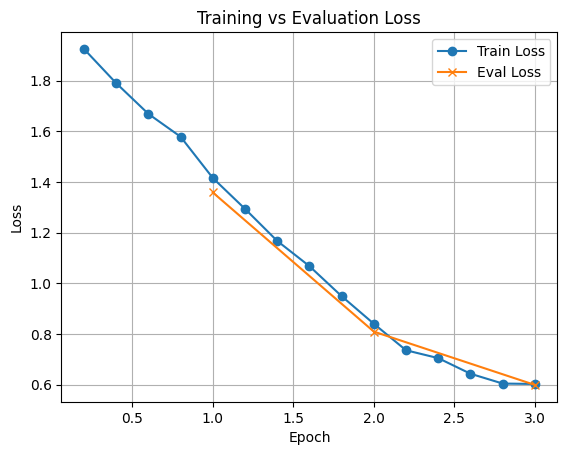

In [25]:
figure, ax = plt.subplots()

ax.plot(train_epochs, train_losses, marker="o", label="Train Loss")
ax.plot(eval_epochs, eval_losses, marker="x", label="Eval Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Evaluation Loss")

ax.legend()
ax.grid()

plt.show()

In [26]:
prompt

'Return ONLY valid JSON.\n\nAvailable tools:\n- search_flights(origin, destination, departure_date, return_date)\n- search_hotels(location, check_in_date, check_out_date)\n- plan_trip(destination, start_date, end_date, budget_level)\n- check_weather(location, date)\n\nUse exact tool names and exact argument keys.\n\nUser request:\nI want to go from San Diego to New York from 2026-05-10 to 2026-05-15 and keep it a medium budget.'

In [27]:
response = generate_response(model, tokenizer, prompt)
print(response)

{"tool": "search_flights", "arguments": {"origin": "San Diego", "destination": "New York", "departure_date": "2026-05-10", "return_date": "2026-05-15"}}


In [28]:
print(test_dataset["text"][0])

<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- check_weather(location, date)

Use exact tool names and exact argument keys.

User request:
Travel request: I want an itinerary for London from 2026-05-10 to 2026-05-15 with high spending. Please respond with JSON only.<|im_end|>
<|im_start|>assistant
{"tool": "plan_trip", "arguments": {"destination": "London", "start_date": "2026-05-10", "end_date": "2026-05-15", "budget_level": "HIGH"}}<|im_end|>



In [29]:
df = evaluate_tool_calling_df(model, tokenizer, test_dataset)
df.head()

,prompt,pred_tool,actual_tool,tool_match,pred_arguments,actual_arguments,arguments_match,valid_json,prediction_raw,reference_raw
0,Return ONLY valid JSON.\n\nAvailable tools:\n-...,search_flights,plan_trip,False,"{'origin': 'London', 'destination': 'London', ...","{'destination': 'London', 'start_date': '2026-...",False,True,"{""tool"": ""search_flights"", ""arguments"": {""orig...","{""tool"": ""plan_trip"", ""arguments"": {""destinati..."
1,Return ONLY valid JSON.\n\nAvailable tools:\n-...,plan_trip,plan_trip,True,"{'destination': 'Rome', 'start_date': '2026-09...","{'destination': 'Rome', 'start_date': '2026-09...",False,True,"{""tool"": ""plan_trip"", ""arguments"": {""destinati...","{""tool"": ""plan_trip"", ""arguments"": {""destinati..."
2,Return ONLY valid JSON.\n\nAvailable tools:\n-...,search_hotels,search_hotels,True,"{'location': 'Honolulu', 'check_in_date': '202...","{'location': 'Honolulu', 'check_in_date': '202...",True,True,"{""tool"": ""search_hotels"", ""arguments"": {""locat...","{""tool"": ""search_hotels"", ""arguments"": {""locat..."
3,Return ONLY valid JSON.\n\nAvailable tools:\n-...,search_hotels,search_hotels,True,None,"{'location': 'New York', 'check_in_date': '202...",False,True,"{""tool"": ""search_hotels"", ""argument"": ""New Yor...","{""tool"": ""search_hotels"", ""arguments"": {""locat..."
4,Return ONLY valid JSON.\n\nAvailable tools:\n-...,weather_schemalike,check_weather,False,None,"{'location': 'Paris', 'date': '2026-08-21'}",False,True,"{""tool"": ""weather_schemalike"", ""argument_keys""...","{""tool"": ""check_weather"", ""arguments"": {""locat..."


In [30]:
df.tool_match.value_counts()

tool_match
True     13
False     7
Name: count, dtype: int64

In [31]:
df.arguments_match.value_counts()

arguments_match
False    12
True      8
Name: count, dtype: int64

In [32]:
df.valid_json.value_counts()

valid_json
True     19
False     1
Name: count, dtype: int64

## Train mas

In [33]:
# Increase number of epochs
trainer.args.num_train_epochs = 6
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.280934,0.277369
2,0.189180,0.208017
3,0.174724,0.175455
4,0.151435,0.164436
5,0.154450,0.156368
6,0.142311,0.153867


TrainOutput(global_step=150, training_loss=0.2025536612669627, metrics={'train_runtime': 114.0908, 'train_samples_per_second': 5.259, 'train_steps_per_second': 1.315, 'total_flos': 250169887411200.0, 'train_loss': 0.2025536612669627})

## Model v2 Eval

In [34]:
train_epochs, train_losses, eval_epochs, eval_losses = log_parser(trainer)

print(train_epochs)
print(train_losses)
print(eval_epochs)
print(eval_losses)

[0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8, 5.0, 5.2, 5.4, 5.6, 5.8, 6.0]
[0.5015454292297363, 0.3921631336212158, 0.3463198900222778, 0.29503166675567627, 0.2809340715408325, 0.269990062713623, 0.24251480102539064, 0.22295479774475097, 0.1995216727256775, 0.18917995691299438, 0.1813502073287964, 0.18554842472076416, 0.17063754796981812, 0.17956337928771973, 0.17472387552261354, 0.16600748300552368, 0.16528563499450682, 0.15186114311218263, 0.15959925651550294, 0.15143468379974365, 0.15572882890701295, 0.14587341547012328, 0.14498655796051024, 0.13881748914718628, 0.15445035696029663, 0.14385584592819214, 0.13030943870544434, 0.15341682434082032, 0.14069305658340453, 0.14231090545654296]
[1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
[0.2773692011833191, 0.20801731944084167, 0.17545516788959503, 0.16443559527397156, 0.15636788308620453, 0.1538674235343933]


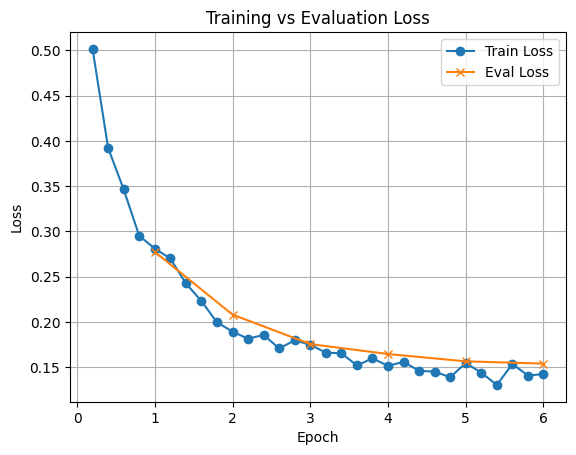

In [35]:
figure, ax = plt.subplots()

ax.plot(train_epochs, train_losses, marker="o", label="Train Loss")
ax.plot(eval_epochs, eval_losses, marker="x", label="Eval Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Evaluation Loss")

ax.legend()
ax.grid()

plt.show()

In [36]:
prompt 

'Return ONLY valid JSON.\n\nAvailable tools:\n- search_flights(origin, destination, departure_date, return_date)\n- search_hotels(location, check_in_date, check_out_date)\n- plan_trip(destination, start_date, end_date, budget_level)\n- check_weather(location, date)\n\nUse exact tool names and exact argument keys.\n\nUser request:\nI want to go from San Diego to New York from 2026-05-10 to 2026-05-15 and keep it a medium budget.'

In [37]:
generate_response(model, tokenizer, prompt)

'{"tool": "plan_trip", "arguments": {"destination": "New York", "start_date": "2026-05-10", "end_date": "2026-05-15", "budget_level": "MEDIUM"}}'

In [38]:
df_2 = evaluate_tool_calling_df(model, tokenizer, test_dataset)
df_2.head()

,prompt,pred_tool,actual_tool,tool_match,pred_arguments,actual_arguments,arguments_match,valid_json,prediction_raw,reference_raw
0,Return ONLY valid JSON.\n\nAvailable tools:\n-...,plan_trip,plan_trip,True,"{'destination': 'London', 'start_date': '2026-...","{'destination': 'London', 'start_date': '2026-...",True,True,"{""tool"": ""plan_trip"", ""arguments"": {""destinati...","{""tool"": ""plan_trip"", ""arguments"": {""destinati..."
1,Return ONLY valid JSON.\n\nAvailable tools:\n-...,plan_trip,plan_trip,True,"{'destination': 'Rome', 'start_date': '2026-09...","{'destination': 'Rome', 'start_date': '2026-09...",True,True,"{""tool"": ""plan_trip"", ""arguments"": {""destinati...","{""tool"": ""plan_trip"", ""arguments"": {""destinati..."
2,Return ONLY valid JSON.\n\nAvailable tools:\n-...,search_hotels,search_hotels,True,"{'location': 'Honolulu', 'check_in_date': '202...","{'location': 'Honolulu', 'check_in_date': '202...",True,True,"{""tool"": ""search_hotels"", ""arguments"": {""locat...","{""tool"": ""search_hotels"", ""arguments"": {""locat..."
3,Return ONLY valid JSON.\n\nAvailable tools:\n-...,search_hotels,search_hotels,True,"{'location': 'New York', 'check_in_date': '202...","{'location': 'New York', 'check_in_date': '202...",True,True,"{""tool"": ""search_hotels"", ""arguments"": {""locat...","{""tool"": ""search_hotels"", ""arguments"": {""locat..."
4,Return ONLY valid JSON.\n\nAvailable tools:\n-...,check_weather,check_weather,True,"{'location': 'Paris', 'date': '2026-08-21'}","{'location': 'Paris', 'date': '2026-08-21'}",True,True,"{""tool"": ""check_weather"", ""arguments"": {""locat...","{""tool"": ""check_weather"", ""arguments"": {""locat..."


In [39]:
df_2.tool_match.value_counts()

tool_match
True    20
Name: count, dtype: int64

In [40]:
df_2.arguments_match.value_counts()

arguments_match
True    20
Name: count, dtype: int64

In [41]:
df_2.valid_json.value_counts()

valid_json
True    20
Name: count, dtype: int64

In [ ]:
trainer.model.save_pretrained(f"{final_path}/{ts}_final_adapter_v2")
tokenizer.save_pretrained(f"{final_path}/{ts}_final_adapter_v2")

In [42]:
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype="auto",
    device_map="auto"
)
print(base_model)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 960, padding_idx=2)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=960, out_features=960, bias=False)
          (k_proj): Linear(in_features=960, out_features=320, bias=False)
          (v_proj): Linear(in_features=960, out_features=320, bias=False)
          (o_proj): Linear(in_features=960, out_features=960, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=960, out_features=2560, bias=False)
          (up_proj): Linear(in_features=960, out_features=2560, bias=False)
          (down_proj): Linear(in_features=2560, out_features=960, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((960,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((960,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((960,), eps=1e-05)
    (r

In [43]:
peft_config = LoraConfig(
    r=4,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj","k_proj","v_proj","o_proj"]
)
model = get_peft_model(base_model, peft_config).to(base_model.device)
model.train()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(49152, 960, padding_idx=2)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=960, out_features=960, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=960, out_features=4, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=4, out_features=960, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora

In [44]:
model.print_trainable_parameters()

trainable params: 819,200 || all params: 362,640,320 || trainable%: 0.2259


In [45]:
training_args = SFTConfig(
    output_dir=str(output_dir/"smollm-tool-routing-lora-r4"),
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    learning_rate=2e-4,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    report_to="none",
    remove_unused_columns=False,
    dataset_text_field="text",
    use_cpu=False,
    bf16=False,
    fp16=False,
)

In [46]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
)
trainer.train()

Epoch,Training Loss,Validation Loss
1,1.429162,1.373619
2,0.858207,0.828698
3,0.614376,0.612177


TrainOutput(global_step=75, training_loss=1.1504033756256105, metrics={'train_runtime': 58.1452, 'train_samples_per_second': 5.159, 'train_steps_per_second': 1.29, 'total_flos': 124760953382400.0, 'train_loss': 1.1504033756256105})

In [47]:
trainer.args.num_train_epochs = 6
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.275995,0.271845
2,0.185844,0.205957
3,0.173224,0.174185
4,0.149554,0.164095
5,0.153512,0.155576
6,0.141708,0.153666


TrainOutput(global_step=150, training_loss=0.20170476158459982, metrics={'train_runtime': 114.7026, 'train_samples_per_second': 5.231, 'train_steps_per_second': 1.308, 'total_flos': 249521906764800.0, 'train_loss': 0.20170476158459982})

In [48]:
df = evaluate_tool_calling_df(model, tokenizer, test_dataset)
df.head()

,prompt,pred_tool,actual_tool,tool_match,pred_arguments,actual_arguments,arguments_match,valid_json,prediction_raw,reference_raw
0,Return ONLY valid JSON.\n\nAvailable tools:\n-...,plan_trip,plan_trip,True,"{'destination': 'London', 'start_date': '2026-...","{'destination': 'London', 'start_date': '2026-...",True,True,"{""tool"": ""plan_trip"", ""arguments"": {""destinati...","{""tool"": ""plan_trip"", ""arguments"": {""destinati..."
1,Return ONLY valid JSON.\n\nAvailable tools:\n-...,plan_trip,plan_trip,True,"{'destination': 'Rome', 'start_date': '2026-09...","{'destination': 'Rome', 'start_date': '2026-09...",True,True,"{""tool"": ""plan_trip"", ""arguments"": {""destinati...","{""tool"": ""plan_trip"", ""arguments"": {""destinati..."
2,Return ONLY valid JSON.\n\nAvailable tools:\n-...,search_hotels,search_hotels,True,"{'location': 'Honolulu', 'check_in_date': '202...","{'location': 'Honolulu', 'check_in_date': '202...",True,True,"{""tool"": ""search_hotels"", ""arguments"": {""locat...","{""tool"": ""search_hotels"", ""arguments"": {""locat..."
3,Return ONLY valid JSON.\n\nAvailable tools:\n-...,search_hotels,search_hotels,True,"{'location': 'New York', 'check_in_date': '202...","{'location': 'New York', 'check_in_date': '202...",True,True,"{""tool"": ""search_hotels"", ""arguments"": {""locat...","{""tool"": ""search_hotels"", ""arguments"": {""locat..."
4,Return ONLY valid JSON.\n\nAvailable tools:\n-...,check_weather,check_weather,True,"{'location': 'Paris', 'date': '2026-08-21'}","{'location': 'Paris', 'date': '2026-08-21'}",True,True,"{""tool"": ""check_weather"", ""arguments"": {""locat...","{""tool"": ""check_weather"", ""arguments"": {""locat..."


In [49]:
df.tool_match.value_counts()

tool_match
True    20
Name: count, dtype: int64

In [50]:
df.arguments_match.value_counts()

arguments_match
True    20
Name: count, dtype: int64

In [51]:
df.valid_json.value_counts()

valid_json
True    20
Name: count, dtype: int64